# 🌍 World Economic Indicators Analysis
## تحليل المؤشرات الاقتصادية العالمية

**المصدر:** World Bank - World Development Indicators  
**الفترة الزمنية:** 1960 - 2014  
**المؤشرات المُحللة:**
- 📈 GDP (الناتج المحلي الإجمالي)
- 💸 التضخم
- 👥 البطالة

**هدف التحليل:** دراسة الأداء الاقتصادي لمصر مقارنةً بكوريا الجنوبية، واستكشاف العلاقات بين المؤشرات الاقتصادية الرئيسية.

---
## 1️⃣ استيراد المكتبات

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# ضبط شكل الجرافات
sns.set_theme(style='whitegrid')
plt.rcParams['figure.dpi'] = 100

---
## 2️⃣ تحميل الداتا واستكشافها (EDA)

In [2]:
# قراءة الداتا
df = pd.read_csv('indicators_small.csv')

# شكل الداتا: كام صف وكام عمود؟
print(f'عدد الصفوف: {df.shape[0]:,}')
print(f'عدد الأعمدة: {df.shape[1]}')

عدد الصفوف: 24,497
عدد الأعمدة: 6


In [3]:
# معلومات عن أنواع البيانات والقيم الناقصة
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 24497 entries, 0 to 24496
Data columns (total 6 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   CountryName    24497 non-null  object 
 1   CountryCode    24497 non-null  object 
 2   IndicatorName  24497 non-null  object 
 3   IndicatorCode  24497 non-null  object 
 4   Year           24497 non-null  int64  
 5   Value          24497 non-null  float64
dtypes: float64(1), int64(1), object(4)
memory usage: 1.1+ MB


In [4]:
# إحصائيات سريعة عن الأعمدة الرقمية
df.describe()

,Year,Value
count,24497.000000,2.449700e+04
mean,1993.814508,3.620131e+11
std,14.392713,2.790710e+12
min,1960.000000,-1.810863e+01
25%,1984.000000,5.700015e+00
50%,1997.000000,1.668580e+01
75%,2006.000000,5.422139e+09
max,2014.000000,7.784511e+13


**ملاحظات من الـ EDA:**
- الداتا **نظيفة تماماً** - لا توجد قيم ناقصة
- الداتا تغطي الفترة من **1960 إلى 2014** (54 سنة)
- فيه تفاوت كبير في الـ Value لأن الداتا تشمل دولاً صغيرة وكبيرة جداً

---
## 3️⃣ تحليل مصر 🇪🇬

In [5]:
# فيلتر بيانات مصر
egypt = df[df['CountryName'] == 'Egypt, Arab Rep.']

# فصل كل مؤشر لوحده
egypt_gdp        = egypt[egypt['IndicatorCode'] == 'NY.GDP.MKTP.CD'].sort_values('Year')
egypt_inflation  = egypt[egypt['IndicatorCode'] == 'FP.CPI.TOTL.ZG'].sort_values('Year')
egypt_unemp      = egypt[egypt['IndicatorCode'] == 'SL.UEM.TOTL.ZS'].sort_values('Year')

print(f'عدد سنوات بيانات مصر: {egypt.shape[0]}')

عدد سنوات بيانات مصر: 128


### 📈 GDP مصر من 1965 إلى 2014

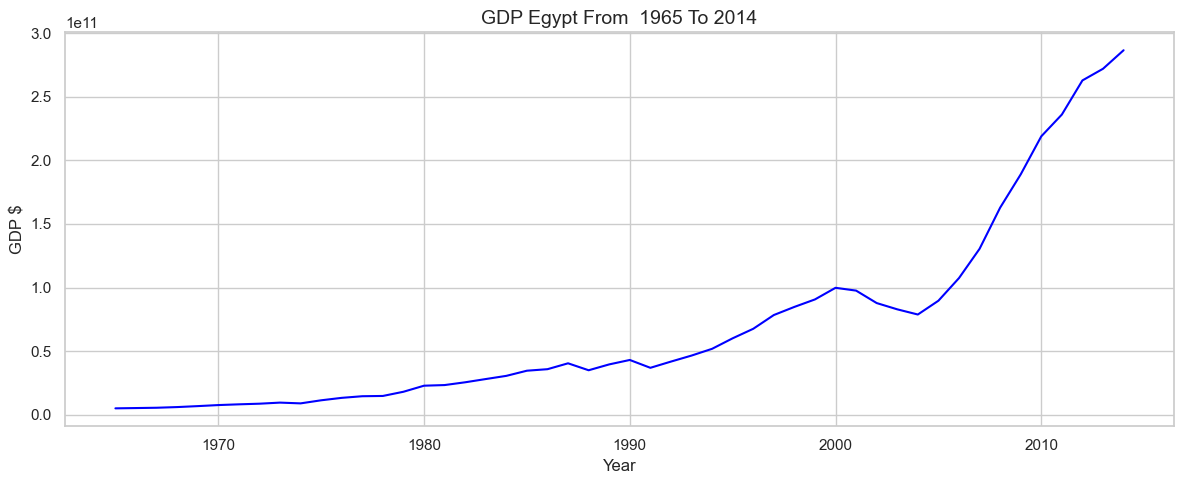

In [18]:
plt.figure(figsize=(12, 5))
sns.lineplot(data=egypt_gdp, x='Year', y='Value', color='blue')
plt.title('GDP Egypt From  1965 To 2014', fontsize=14)
plt.xlabel('Year')
plt.ylabel('GDP $')
plt.tight_layout()
plt.show()

**أبرز الملاحظات:**
- **1974:** انكماش طفيف في الـ GDP بعد حرب أكتوبر 1973
- **2000-2005:** انخفاض واضح بسبب تخفيض قيمة الجنيه المصري وأحداث 11 سبتمبر 2001
- **2005-2014:** طفرة اقتصادية كبيرة بعد الإصلاحات وانفتاح الاستثمار الأجنبي

### 💸 التضخم في مصر من 1961 إلى 2014

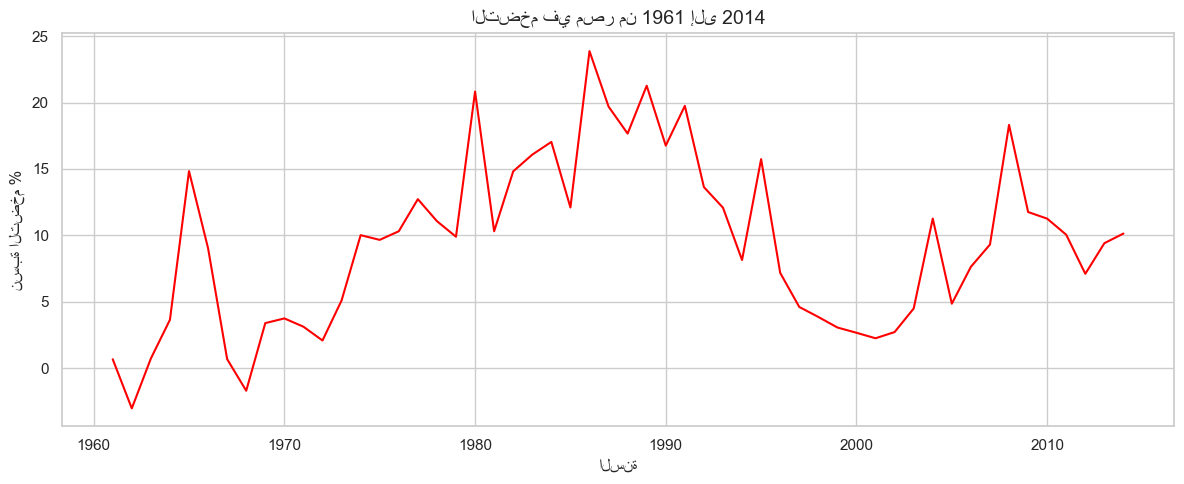

In [7]:
plt.figure(figsize=(12, 5))
sns.lineplot(data=egypt_inflation, x='Year', y='Value', color='red')
plt.title('التضخم في مصر من 1961 إلى 2014', fontsize=14)
plt.xlabel('السنة')
plt.ylabel('نسبة التضخم %')
plt.tight_layout()
plt.show()

**أبرز الملاحظات:**
- **1986-1990:** أعلى معدلات تضخم في تاريخ مصر (وصل إلى 24%)
- **2008:** ارتفاع حاد بسبب ارتفاع أسعار الغذاء عالمياً
- **2011:** انخفاض مفاجئ بعد ثورة يناير بسبب توقف النشاط الاقتصادي
- التضخم في مصر **مرآة للأحداث السياسية** وليس فقط الاقتصادية

### 👥 البطالة في مصر من 1991 إلى 2014

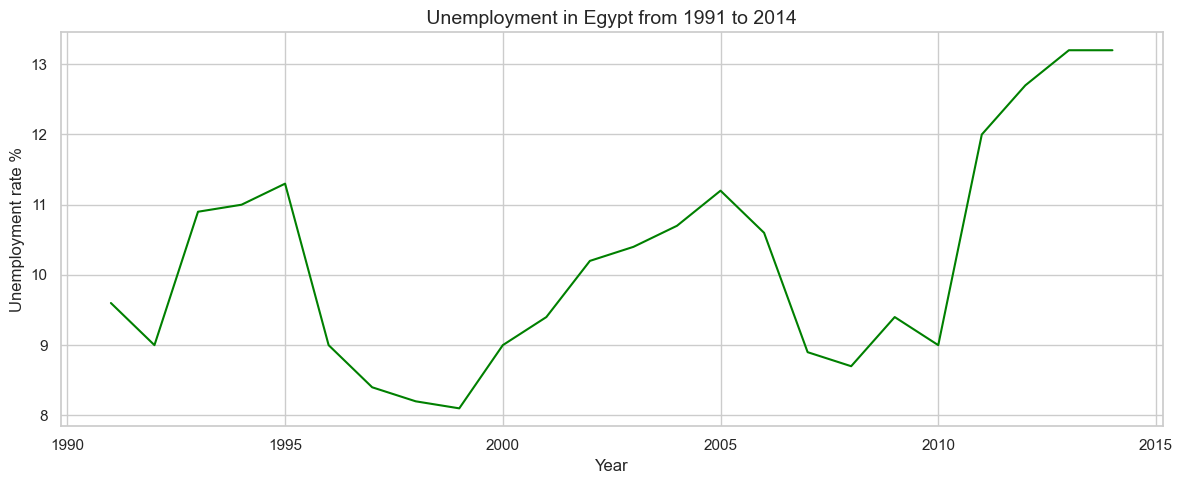

In [17]:
plt.figure(figsize=(12, 5))
sns.lineplot(data=egypt_unemp, x='Year', y='Value', color='green')
plt.title(' Unemployment in Egypt from 1991 to 2014 ', fontsize=14)
plt.xlabel('Year')
plt.ylabel('Unemployment rate %')
plt.tight_layout()
plt.show()

**أبرز الملاحظات:**
- **2005-2008:** ظاهرة "Jobless Growth" - الاقتصاد ينمو بدون خلق فرص عمل كافية
- **بعد 2011:** ارتفاع حاد من 9% إلى 13% في سنتين فقط بسبب توقف السياحة والاستثمار
- مصر تعاني من مشكلة هيكلية: الاقتصاد يكبر لكنه لا يوزع الفرص بالتساوي

---
## 4️⃣ مصر 🇪🇬 vs كوريا الجنوبية 🇰🇷

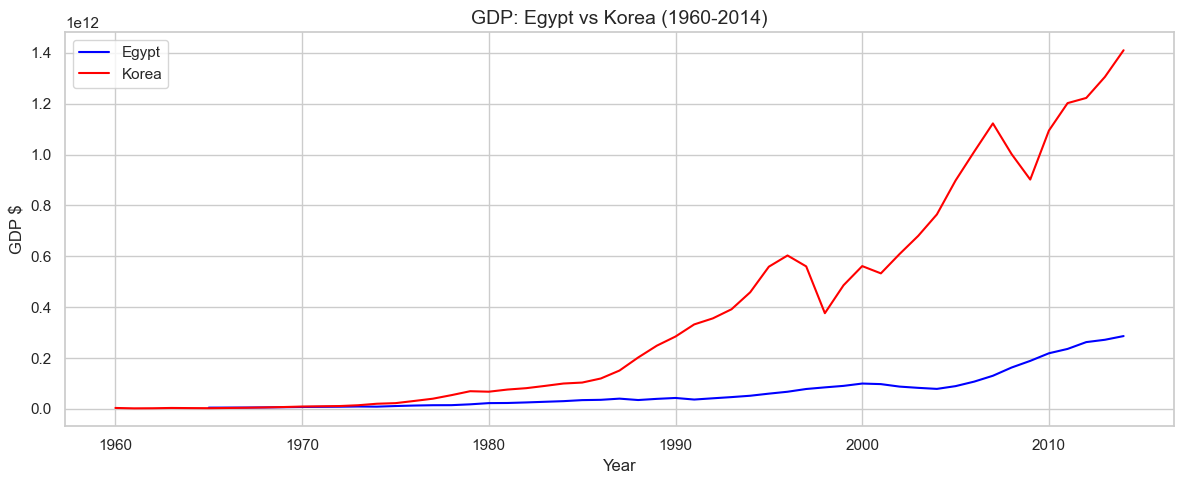

In [16]:
# فيلتر بيانات كوريا الجنوبية
korea = df[df['CountryName'] == 'Korea, Rep.']
korea_gdp = korea[korea['IndicatorCode'] == 'NY.GDP.MKTP.CD'].sort_values('Year')

plt.figure(figsize=(12, 5))
sns.lineplot(data=egypt_gdp, x='Year', y='Value', color='blue', label='Egypt')
sns.lineplot(data=korea_gdp, x='Year', y='Value', color='red', label='Korea')
plt.title('GDP: Egypt vs Korea (1960-2014)', fontsize=14)
plt.xlabel('Year')
plt.ylabel('GDP $')
plt.legend()
plt.tight_layout()
plt.show()

**أبرز الملاحظات:**
- **1960:** الدولتان بدأتا من نفس النقطة تقريباً
- **بعد 1980:** كوريا بدأت تنفصل بشكل واضح
- **2014:** كوريا وصلت إلى **1.4 تريليون دولار** مقابل **300 مليار** لمصر
- **السبب الجوهري:** كوريا استثمرت في التعليم والصناعة وبنت شركات عالمية مثل Samsung وHyundai

---
## 5️⃣ أعلى 10 دول في التضخم عام 2014

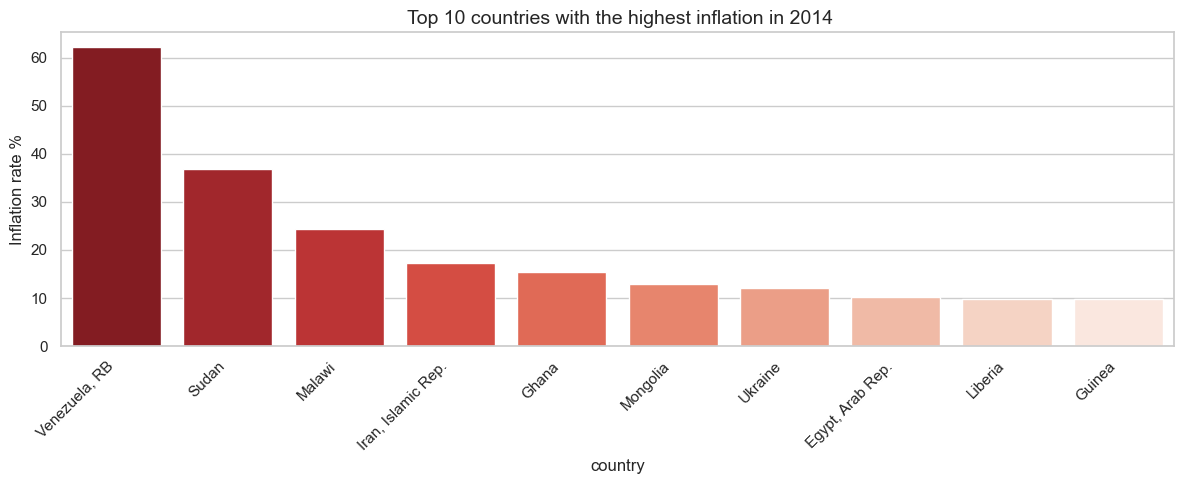

In [13]:
# أعلى 10 دول تضخم في 2014
latest_inflation = df[
    (df['IndicatorCode'] == 'FP.CPI.TOTL.ZG') &
    (df['Year'] == 2014)
].sort_values('Value', ascending=False).head(10)

plt.figure(figsize=(12, 5))
sns.barplot(
    data=latest_inflation,
    x='CountryName',
    y='Value',
    hue='CountryName',
    palette='Reds_r',
    legend=False
)
plt.title(' Top 10 countries with the highest inflation in 2014', fontsize=14)
plt.xlabel('country')
plt.ylabel('Inflation rate %')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

**أبرز الملاحظات:**
- **فنزويلا** في المركز الأول بتضخم **62%** - أزمة اقتصادية حادة بسبب الاعتماد على البترول
- **مصر** في المركز الثامن بتضخم **10%** - من أعلى الدول في العالم
- معظم الدول في هذه القائمة تعاني من عدم الاستقرار السياسي أو الاعتماد على مورد واحد

---
## 6️⃣ العلاقة بين المؤشرات الاقتصادية في مصر (Heatmap)

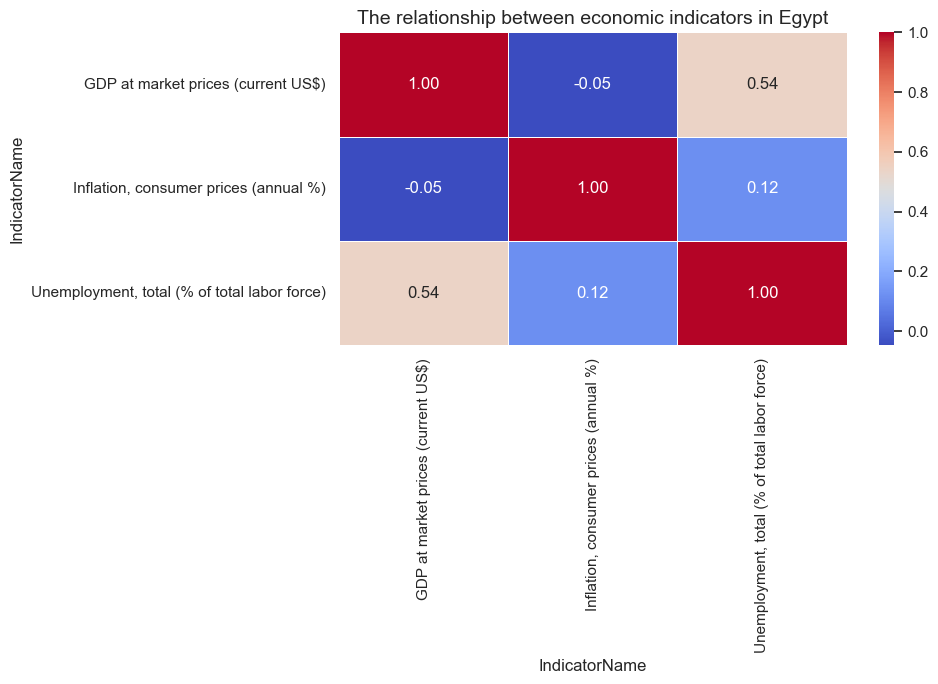

In [12]:
# تحويل الداتا من Long Format إلى Wide Format
egypt_pivot = egypt.pivot_table(
    index='Year',
    columns='IndicatorName',
    values='Value'
)

plt.figure(figsize=(10, 7))
sns.heatmap(
    egypt_pivot.corr(),
    annot=True,
    cmap='coolwarm',
    fmt='.2f',
    linewidths=0.5
)
plt.title('The relationship between economic indicators in Egypt', fontsize=14)
plt.tight_layout()
plt.show()

**قراءة الـ Heatmap:**
- **GDP والتضخم = -0.05:** لا توجد علاقة واضحة بينهما في مصر
- **GDP والبطالة = 0.54:** علاقة طردية - ظاهرة "Jobless Growth" واضحة
- **التضخم والبطالة = 0.12:** علاقة ضعيفة جداً

> **Insight:** مصر لا تتبع قواعد الاقتصاد الكلاسيكي، مما يدل على وجود مشاكل هيكلية عميقة في بنية الاقتصاد المصري

---
## 7️⃣ الخلاصة والنتائج

### أهم ما توصل إليه التحليل:

1. **مصر والـ GDP:** نمو مستمر على مدار 54 سنة، لكنه تأثر بشكل واضح بالأحداث السياسية (1973، 2001، 2011)

2. **التضخم:** التضخم في مصر مرتبط بالأحداث السياسية أكثر من الاقتصادية

3. **البطالة:** مصر تعاني من ظاهرة Jobless Growth - الاقتصاد ينمو بدون خلق فرص عمل كافية

4. **مقارنة مصر وكوريا:** رغم أنهما بدأتا من نفس النقطة، كوريا حققت تقدماً استثنائياً بسبب الاستثمار في التعليم والصناعة

5. **مصر والتضخم العالمي:** مصر من أعلى 10 دول في التضخم عام 2014